In [1]:
import os
import sys
dir_path = "/qumulo/shared_data/aofei_summer/RegTok/RegLLM"
sys.path.insert(0, dir_path)
os.environ['CUDA_VISIBLE_DEVICES'] = "2"
os.environ["HF_HUB_CACHE"]="/qumulo/shared_data/aofei_summer/LLMs"
from llava.eval.cli_v1 import RegLLMChatbot

/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
model_dir = "/qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1105_full_instruct_71k_nosep"
model_args = {
        "model_name_or_path": "Qwen/Qwen3-8B",
        "pretrained_llm_path": model_dir,
        "tokenizer_path": "/qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1105_full_instruct_71k_nosep",
        "peft_path": None,
        "regtok_config_path": "/qumulo/shared_data/aofei_summer/RegTok/source/tokenizer/regtok_config.yaml",
        "regtok_weight_path": "/qumulo/shared_data/aofei_summer/intern_records/RegTok/checkpoints/RegTok_pipeline_full_wo_quant/002-RegTok/checkpoints/0079280.pt",
        "use_regtok": True,
        "mm_vision_vq_type": "RegTok",
        "vision_tower": "/qumulo/shared_data/aofei_summer/CLIPs/unimed_clip_vit_l14.pt",
        "mm_use_im_start_end": False,
        "mm_use_im_patch_token": True,
        "mm_vision_select_feature": "patch",
        "mm_patch_merge_type": "flat",
        "mm_projector_type": "mlp2x_gelu",
        "pretrain_mm_mlp_adapter": None,
        "mm_vision_select_layer": -1,
        "use_region_tokens": True,
        "use_sep_proj": False,
        "use_seg_loss": True,
        "output_segmentation": True,
        "modality_num": 18,
        "codebook_size": 32,
        "train_all_embeddings": True,
        "load_codebook_embeddings": False,
        "use_lightweight_decoder": False,
        "resize_embedding": False,
        # "lora_r": 64,
        # "lora_alpha": 64,
        # # "lora_dropout": 0.05,
        "use_moe": False,

    }

In [3]:
bot = RegLLMChatbot(model_dir, model_args=model_args, device="cuda")

loading model from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1105_full_instruct_71k_nosep
use RegSegForCausalLM!
576 codebook_token_ids
Initializing RegSegForCausalLM with config: LlavaQwenConfig {
  "architectures": [
    "RegSegForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "freeze_mm_mlp_adapter": false,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "image_aspect_ratio": "square",
  "initializer_range": 0.02,
  "intermediate_size": 12288,
  "max_position_embeddings": 40960,
  "max_window_layers": 36,
  "mm_hidden_size": 1024,
  "mm_patch_merge_type": "flat",
  "mm_projector_lr": null,
  "mm_projector_type": "mlp2x_gelu",
  "mm_use_im_patch_token": false,
  "mm_use_im_start_end": false,
  "mm_vision_select_feature": "patch",
  "mm_vision_select_layer": -2,
  "mm_vision_tower": "/qumulo/shared_data/aofei_summer/CLIPs/unimed_clip_vit_l14.pt",
  "mm_vision_tuning_

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 55.94it/s]
Some weights of the model checkpoint at /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1105_full_instruct_71k_nosep were not used when initializing RegSegForCausalLM: ['model.vision_tower.vision_tower.image_encoder.class_embedding', 'model.vision_tower.vision_tower.image_encoder.conv1.weight', 'model.vision_tower.vision_tower.image_encoder.ln_post.bias', 'model.vision_tower.vision_tower.image_encoder.ln_post.weight', 'model.vision_tower.vision_tower.image_encoder.ln_pre.bias', 'model.vision_tower.vision_tower.image_encoder.ln_pre.weight', 'model.vision_tower.vision_tower.image_encoder.positional_embedding', 'model.vision_tower.vision_tower.image_encoder.proj', 'model.vision_tower.vision_tower.image_encoder.transformer.resblocks.0.attn.in_proj_bias', 'model.vision_tower.vision_tower.image_encoder.transformer.resblocks.0.attn.in_proj_weight', 'model.vision_tower.vision_tower.image_encoder.transform

load vision tower!
Number of stacks: 1
Upsample mode: conv
tokenflow load from: /qumulo/shared_data/aofei_summer/intern_records/RegTok/checkpoints/RegTok_pipeline_full_wo_quant/002-RegTok/checkpoints/0079280.pt
tokenflow model load success!!
mm_projector parameters unfrozen.
pre loading complete!
Loading tokenizer from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1105_full_instruct_71k_nosep
Loading tokenizer from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1105_full_instruct_71k_nosep


In [4]:
# bot.model

In [5]:
# bot = RegLLMChatbot(model_dir, model_args=model_args, device="cuda")
# bot.model = bot.model.base_model.model

In [9]:
# bot.model

In [4]:
bot.inference("Please segment the liver.", images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg", output_seg=False)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


(['assistant\nThe liver is segmented as [M0_16].'],
 tensor([[151644,  77091,    198,    785,  25506,    374,  84945,    438,    220,
          151685,     13, 151645]], device='cuda:0'))

In [23]:
answers = bot.inference("On breast ultrasound, what abnormality is identified and how would you segment it?", images="/qumulo/shared_data/aofei_summer/data/BiomedParse/BreastUS/BreastUS/test/malignant (86)_ultrasound_breast.png", output_seg=True)

torch.Size([1, 18, 4096]) torch.Size([1, 18])


In [25]:
import matplotlib.pyplot as plt

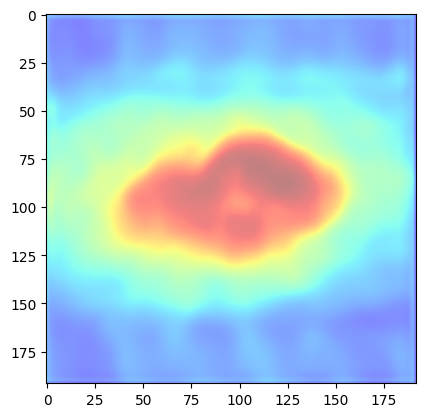

In [26]:
# visualize the mask logits
seg_logits = answers['mask_logits']
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

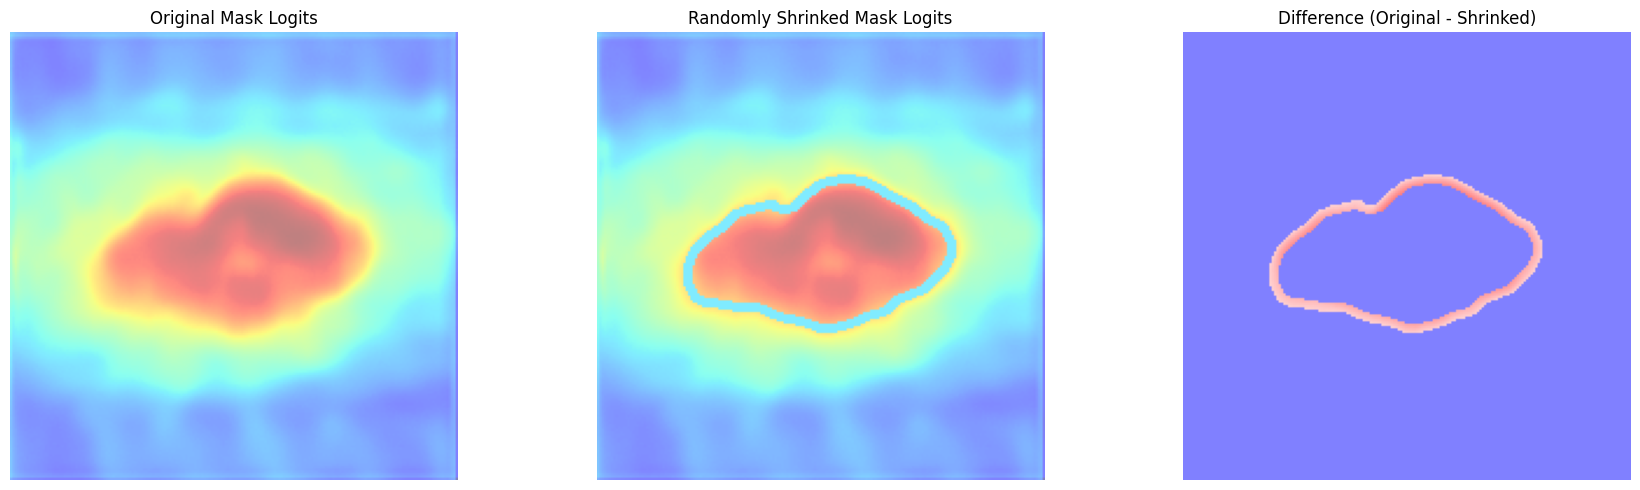

Original - Positive pixels: 5463, Negative pixels: 31401
Shrinked - Positive pixels: 4333, Negative pixels: 32531
Logits range - Original: [-21.750, 9.625]
Logits range - Shrinked: [-21.750, 9.625]


In [ ]:
import cv2
import numpy as np
import random
import torch

def randomly_shrink_mask_core(mask_logits, shrink_ratio_range=(0.1, 0.5)):
    """
    Randomly shrink the core area (positive regions) of mask logits while preserving negative logits
    
    Args:
        mask_logits: tensor of shape (H, W) with values (both positive and negative)
        shrink_ratio_range: tuple of (min_ratio, max_ratio) for random shrinking
    
    Returns:
        shrinked mask logits tensor with preserved negative values
    """
    # Convert to numpy
    mask_np = mask_logits.float().detach().cpu().numpy()
    # Get binary mask of positive regions only
    positive_mask = (mask_np > 0).astype(np.uint8)
    # Random shrink ratio
    shrink_ratio = random.uniform(*shrink_ratio_range)
    # Calculate kernel size based on positive mask area and shrink ratio
    positive_area = np.sum(positive_mask)
    if positive_area == 0:
        return mask_logits  # No positive region to shrink
    
    # Estimate equivalent radius and compute erosion kernel size
    equiv_radius = np.sqrt(positive_area / np.pi)
    kernel_size = max(3, int(equiv_radius * shrink_ratio))
    if kernel_size % 2 == 0:
        kernel_size += 1  # Ensure odd size
    
    # Apply morphological erosion to positive mask only
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    eroded_positive_mask = cv2.erode(positive_mask, kernel, iterations=1)
    
    # Create output: keep negative logits, only modify positive region
    mask_np_shrunk = mask_np.copy()
    # Set regions that were positive but now eroded to a negative value (e.g., mean of negative logits or zero)
    removed_region = (positive_mask == 1) & (eroded_positive_mask == 0)
    # Option 1: Set to zero
    # mask_np_shrunk[removed_region] = 0
    # Option 2: Set to mean of negative logits
    negative_values = mask_np[mask_np < 0]
    if len(negative_values) > 0:
        mask_np_shrunk[removed_region] = np.mean(negative_values)
    else:
        mask_np_shrunk[removed_region] = -1.0  # Default negative value
    
    # Convert back to tensor
    mask_shrunk = torch.from_numpy(mask_np_shrunk).to(mask_logits.device).to(mask_logits.dtype)
    
    return mask_shrunk, removed_region

# Apply to your mask logits
seg_logits_original = seg_logits[0][0].float()
seg_logits_shrunk, removed_region = randomly_shrink_mask_core(seg_logits_original, shrink_ratio_range=(0.2, 0.4))

# Visualize comparison with color overlay for removed region
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
im0 = axes[0].imshow(seg_logits_original.detach().cpu().numpy(), cmap='jet')
axes[0].set_title('Original Mask Logits')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Shrinked with removed region overlay
shrinked_np = seg_logits_shrunk.detach().cpu().numpy()
im1 = axes[1].imshow(shrinked_np, cmap='jet')
# Overlay removed region with semi-transparent red
axes[1].imshow(np.ma.masked_where(~removed_region, removed_region), 
               cmap='Reds', alpha=0.4, vmin=0, vmax=1)
axes[1].set_title('Shrinked (Red = Removed Area)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Difference map
diff = seg_logits_original.detach().cpu().numpy() - shrinked_np
im2 = axes[2].imshow(diff, cmap='bwr', vmin=-diff.max(), vmax=diff.max())
axes[2].set_title('Difference (Original - Shrinked)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Original - Positive: {(seg_logits_original > 0).sum().item()}, Negative: {(seg_logits_original < 0).sum().item()}")
print(f"Shrinked - Positive: {(seg_logits_shrunk > 0).sum().item()}, Negative: {(seg_logits_shrunk < 0).sum().item()}")
print(f"Removed pixels: {removed_region.sum()}")
print(f"Logits range - Original: [{seg_logits_original.min().item():.3f}, {seg_logits_original.max().item():.3f}]")
print(f"Logits range - Shrinked: [{seg_logits_shrunk.min().item():.3f}, {seg_logits_shrunk.max().item():.3f}]")

In [21]:
seg_logits_shrunk

tensor([[-0., -0., -0.,  ..., -0., -0., -0.],
        [-0., -0., -0.,  ..., -0., -0., -0.],
        [-0., -0., -0.,  ..., -0., -0., -0.],
        ...,
        [-0., -0., -0.,  ..., -0., -0., -0.],
        [-0., -0., -0.,  ..., -0., -0., -0.],
        [-0., -0., -0.,  ..., -0., -0., -0.]], device='cuda:0')